In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def integral_approx(a, b, n, method):
    x = np.linspace(a, b, n+1)
    h = (b - a) / n
    if method == 'left':
        xi = x[:-1]
        S = h * np.sum(np.cos(2*xi))
    elif method == 'right':
        xi = x[1:]
        S = h * np.sum(np.cos(2*xi))
    elif method == 'mid':
        xi = (x[:-1] + x[1:]) / 2
        S = h * np.sum(np.cos(2*xi))
    elif method == 'trap':
        xi = np.cos(2*x)
        S = h * (xi[0]/2 + np.sum(xi[1:-1]) + xi[-1]/2)
    else:
        raise ValueError("Unknown method")
    return S, x, xi  # возвращаем узлы и точки оснащения для отрисовки

In [4]:
def plot_riemann(a, b, n, method):
    S, x_nodes, xi = integral_approx(a, b, n, method)
    x_dense = np.linspace(a, b, 500)
    y_dense = np.cos(2*x_dense)

    plt.figure(figsize=(8,5))
    plt.plot(x_dense, y_dense, 'b-', label='f(x)=cos(2x)')

    # Рисуем прямоугольники/трапеции
    h = (b - a) / n
    for i in range(n):
        x_left = x_nodes[i]
        x_right = x_nodes[i+1]
        if method == 'trap':
            # для трапеции рисуем многоугольник
            y_left = np.cos(2*x_left)
            y_right = np.cos(2*x_right)
            plt.fill([x_left, x_right, x_right, x_left],
                     [0, 0, y_right, y_left],
                     edgecolor='black', facecolor='cyan', alpha=0.5)
        else:
            # прямоугольник
            height = np.cos(2*xi[i])
            plt.bar(x_left, height, width=h, align='edge',
                    edgecolor='black', facecolor='cyan', alpha=0.5)

    plt.title(f"Метод: {method}, n={n}, I={S:.6f}")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()

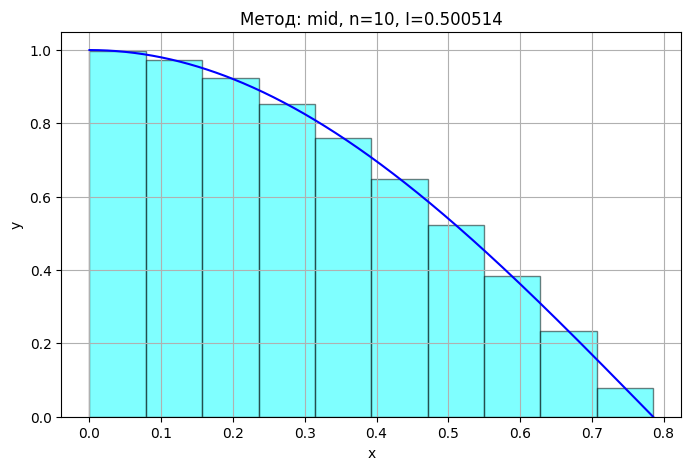

In [5]:
# Пример использования
plot_riemann(0, np.pi/4, 10, 'mid')

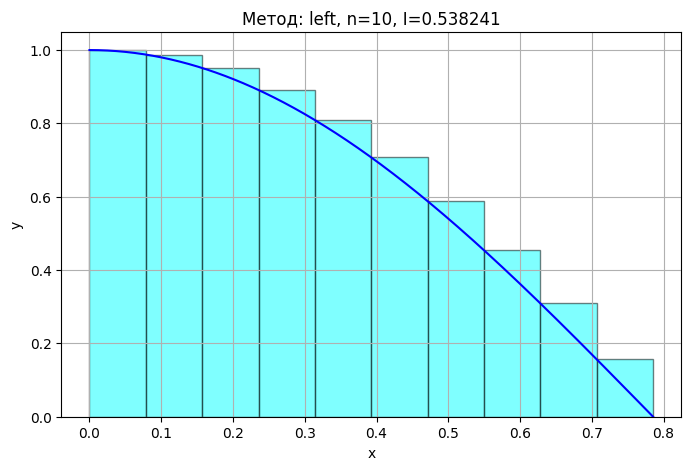

In [6]:
plot_riemann(0, np.pi/4, 10, 'left')

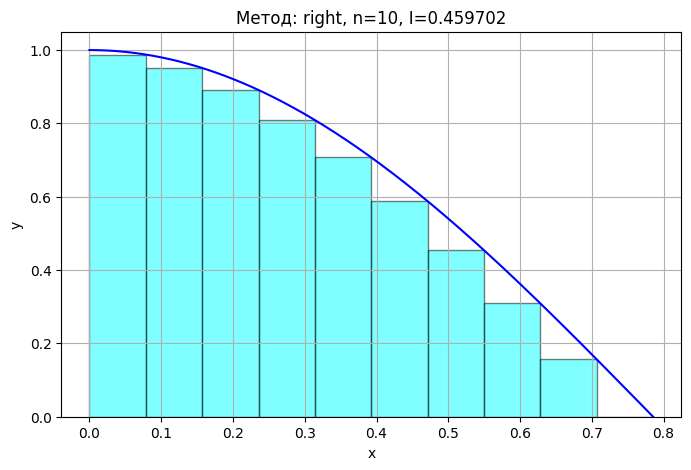

In [7]:
plot_riemann(0, np.pi/4, 10, 'right')

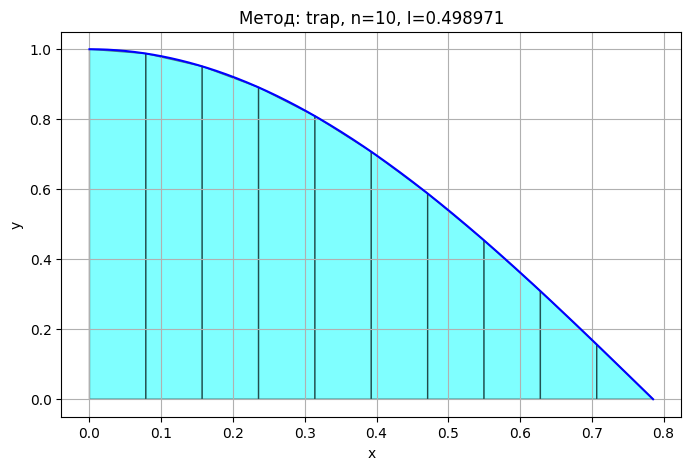

In [8]:
plot_riemann(0, np.pi/4, 10, 'trap')

In [9]:
def integral_approx_pendulum(a, b, n):
    x = np.linspace(a, b-0.000000001, n+1)
    h = (b - a) / n
    
    y = 1/np.sqrt(np.cos(x)-np.cos(b))
    S = h * (y[0]/2 + np.sum(y[1:-1]) + y[-1]/2)

    S *= 2 * np.sqrt(2) / 6.26418
    
    return S  # возвращаем результат апроксимации

In [10]:
integral_approx_pendulum(0, np.pi / 9, 10000000)

1.0109363904137296

In [11]:
integral_approx_pendulum(0, np.pi / 7.2, 10000000)

1.0153640160063284

In [12]:
integral_approx_pendulum(0, np.pi / 6, 10000000)

1.020807229868078

In [57]:
def integral_approx_e(a, b, n, method):
    x = np.linspace(a, b, n+1)
    h = (b - a) / n
    if method == 'left':
        xi = x[:-1]
        S = h * np.sum(np.exp(-xi))
    elif method == 'right':
        xi = x[1:]
        S = h * np.sum(np.exp(-xi))
    elif method == 'mid':
        xi = (x[:-1] + x[1:]) / 2
        S = h * np.sum(np.exp(-xi))
    elif method == 'trap':
        xi = np.exp(-x)
        S = h * (xi[0]/2 + np.sum(xi[1:-1]) + xi[-1]/2)
    else:
        raise ValueError("Unknown method")
    return S, x, xi  # возвращаем узлы и точки оснащения для отрисовки

In [58]:
def plot_riemann_e(a, b, n, method):
    S, x_nodes, xi = integral_approx_e(a, b, n, method)
    x_dense = np.linspace(a, b, 500)
    y_dense = np.exp(-x_dense)

    plt.figure(figsize=(8,5))
    plt.plot(x_dense, y_dense, 'b-', label='f(x)=e^(-x)')

    # Рисуем прямоугольники/трапеции
    h = (b - a) / n
    for i in range(n):
        x_left = x_nodes[i]
        x_right = x_nodes[i+1]
        if method == 'trap':
            # для трапеции рисуем многоугольник
            y_left = np.exp(-x_left)
            y_right = np.exp(-x_right)
            plt.fill([x_left, x_right, x_right, x_left],
                     [0, 0, y_right, y_left],
                     edgecolor='black', facecolor='cyan', alpha=0.5)
        else:
            # прямоугольник
            height = np.exp(-xi[i])
            plt.bar(x_left, height, width=h, align='edge',
                    edgecolor='black', facecolor='cyan', alpha=0.5)

    plt.title(f"Метод: {method}, n={n}, I={S:.6f}")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()

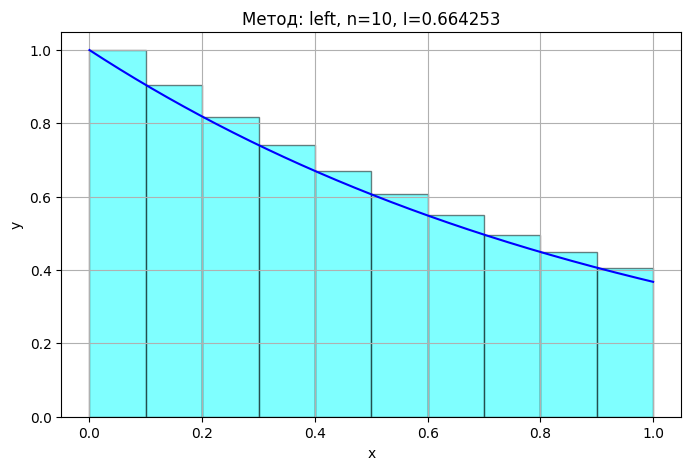

In [59]:
plot_riemann_e(0, 1, 10, 'left')

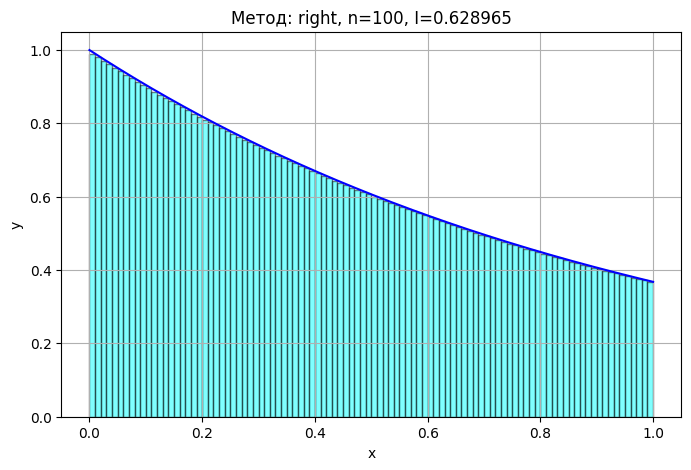

In [60]:
plot_riemann_e(0, 1, 100, 'right')

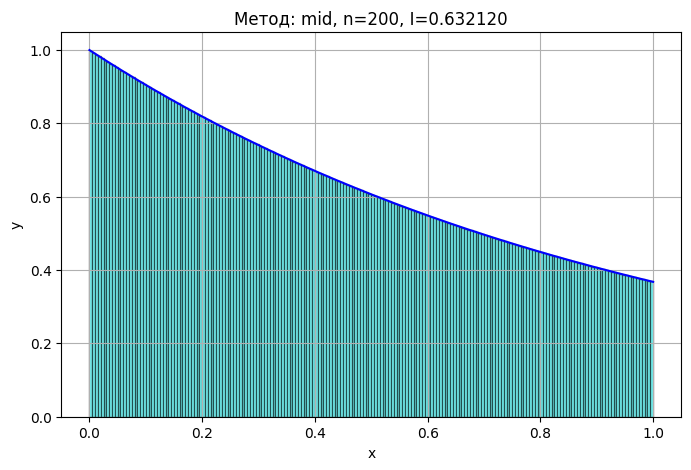

In [61]:
plot_riemann_e(0, 1, 200, 'mid')

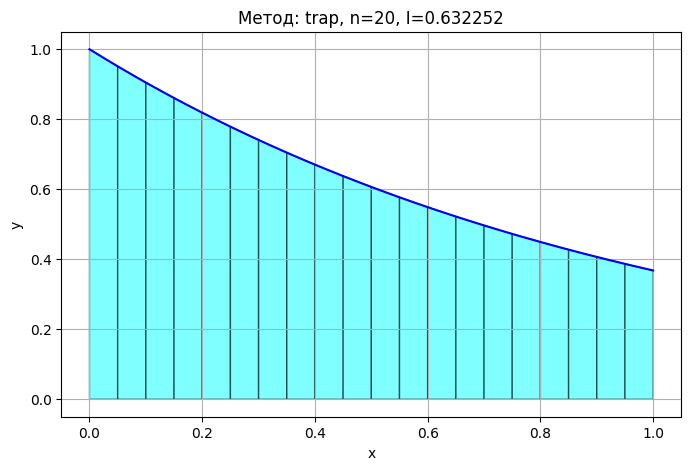

In [63]:
plot_riemann_e(0, 1, 20, 'trap')

In [64]:
def integral_approx_sin(a, b, n, method):
    x = np.linspace(a, b, n+1)
    h = (b - a) / n
    if method == 'left':
        xi = x[:-1]
        S = h * np.sum(np.sin(xi))
    elif method == 'right':
        xi = x[1:]
        S = h * np.sum(np.sin(xi))
    elif method == 'mid':
        xi = (x[:-1] + x[1:]) / 2
        S = h * np.sum(np.sin(xi))
    elif method == 'trap':
        xi = np.sin(x)
        S = h * (xi[0]/2 + np.sum(xi[1:-1]) + xi[-1]/2)
    else:
        raise ValueError("Unknown method")
    return S, x, xi  # возвращаем узлы и точки оснащения для отрисовки

In [65]:
def plot_riemann_sin(a, b, n, method):
    S, x_nodes, xi = integral_approx_sin(a, b, n, method)
    x_dense = np.linspace(a, b, 500)
    y_dense = np.sin(x_dense)

    plt.figure(figsize=(8,5))
    plt.plot(x_dense, y_dense, 'b-', label='f(x)=sin(x)')

    # Рисуем прямоугольники/трапеции
    h = (b - a) / n
    for i in range(n):
        x_left = x_nodes[i]
        x_right = x_nodes[i+1]
        if method == 'trap':
            # для трапеции рисуем многоугольник
            y_left = np.sin(x_left)
            y_right = np.sin(x_right)
            plt.fill([x_left, x_right, x_right, x_left],
                     [0, 0, y_right, y_left],
                     edgecolor='black', facecolor='cyan', alpha=0.5)
        else:
            # прямоугольник
            height = np.sin(xi[i])
            plt.bar(x_left, height, width=h, align='edge',
                    edgecolor='black', facecolor='cyan', alpha=0.5)

    plt.title(f"Метод: {method}, n={n}, I={S:.6f}")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()

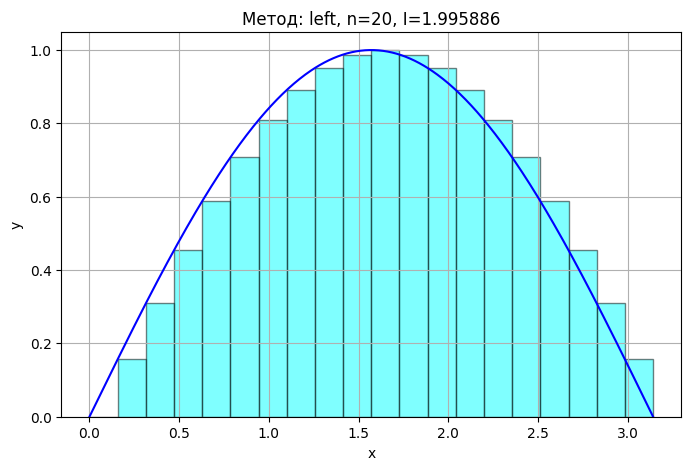

In [66]:
plot_riemann_sin(0, np.pi, 20, 'left')

In [67]:
def integral_approx_x2(a, b, n, method):
    x = np.linspace(a, b, n+1)
    h = (b - a) / n
    if method == 'left':
        xi = x[:-1]
        S = h * np.sum(np.power(xi, 2))
    elif method == 'right':
        xi = x[1:]
        S = h * np.sum(np.power(xi, 2))
    elif method == 'mid':
        xi = (x[:-1] + x[1:]) / 2
        S = h * np.sum(np.power(xi, 2))
    elif method == 'trap':
        xi = np.power(x, 2)
        S = h * (xi[0]/2 + np.sum(xi[1:-1]) + xi[-1]/2)
    else:
        raise ValueError("Unknown method")
    return S, x, xi  # возвращаем узлы и точки оснащения для отрисовки

In [68]:
def plot_riemann_x2(a, b, n, method):
    S, x_nodes, xi = integral_approx_x2(a, b, n, method)
    x_dense = np.linspace(a, b, 500)
    y_dense = np.power(x_dense, 2)

    plt.figure(figsize=(8,5))
    plt.plot(x_dense, y_dense, 'b-', label='f(x)=x^2')

    # Рисуем прямоугольники/трапеции
    h = (b - a) / n
    for i in range(n):
        x_left = x_nodes[i]
        x_right = x_nodes[i+1]
        if method == 'trap':
            # для трапеции рисуем многоугольник
            y_left = np.power(x_left, 2)
            y_right = np.power(x_right, 2)
            plt.fill([x_left, x_right, x_right, x_left],
                     [0, 0, y_right, y_left],
                     edgecolor='black', facecolor='cyan', alpha=0.5)
        else:
            # прямоугольник
            height = np.power(xi[i], 2)
            plt.bar(x_left, height, width=h, align='edge',
                    edgecolor='black', facecolor='cyan', alpha=0.5)

    plt.title(f"Метод: {method}, n={n}, I={S:.6f}")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()

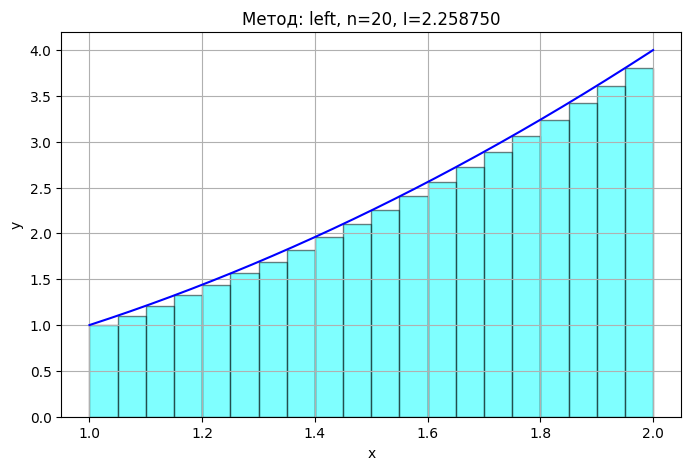

In [69]:
plot_riemann_x2(1, 2, 20, 'left')